Gavriel Blau 
Term Project

In [1]:
# Milestone 1

The global transition towards sustainable energy sources has led to a rapid increase in the adoption of electric vehicles (EVs). As governments and organizations worldwide aim to reduce carbon emissions and dependence on fossil fuels, EVs have become a critical component of the solution. In the United States, the growth of the EV market has been supported by initiatives like the Clean Alternative Fuel Vehicle (CAFV) program, which offers incentives to promote the use of vehicles with lower environmental impact. However, not all EVs meet the criteria for such programs, and understanding the factors that influence eligibility is crucial for manufacturers, policymakers, and consumers alike.

This analysis focuses on exploring the EV market, addressing key questions such as: What attributes of an EV, such as its type, electric range, and pricing, influence its eligibility for CAFV programs? Are there observable trends across manufacturers or vehicle types that can inform future design and policy decisions? The dataset used in this study provides comprehensive information on EV registrations across the U.S., including details about their electric range, manufacturer’s suggested retail price (MSRP), and type (e.g., Battery Electric Vehicles (BEVs) or Plug-in Hybrid Electric Vehicles (PHEVs)).

The primary goal is to uncover patterns and relationships in the dataset that can shed light on the current state of the EV market and its alignment with clean energy incentives. By examining the distribution of vehicle types, electric ranges, and pricing, along with their association with CAFV eligibility, this study aims to provide actionable insights into the evolving landscape of the EV industry. These insights can guide manufacturers in designing vehicles that align with consumer preferences and government standards, ultimately accelerating the adoption of sustainable transportation.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"C:\Users\chezk\OneDrive\Documents\bellevue class 6\EV_Population.csv"
data = pd.read_csv(file_path)

# Display first few rows of the dataset
print(data.head())

# Basic information about the dataset
print(data.info())

  State  Model Year       Make Electric Vehicle Type  Electric Range  \
0    WA        2020      TESLA                   BEV             266   
1    WA        2024        BMW                  PHEV              39   
2    WA        2024        BMW                  PHEV              39   
3    WA        2018      TESLA                   BEV             215   
4    WA        2012  CHEVROLET                  PHEV              35   

   Base MSRP  Legislative District CAFV Eligibility Simple  
0          0                  46.0                Eligible  
1          0                  46.0                Eligible  
2          0                  43.0                Eligible  
3          0                   1.0                Eligible  
4          0                  35.0                Eligible  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92676 entries, 0 to 92675
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   ---------

The bar chart illustrates the top 10 electric vehicle (EV) manufacturers in Washington state by the count of registered vehicles. Tesla dominates the EV market, with significantly higher registrations than any other manufacturer, highlighting its strong foothold in the region. Nissan and Chevrolet follow in second and third place, indicating their popularity in the EV market, albeit with substantially fewer registrations than Tesla. Other manufacturers, such as Toyota, BMW, and Jeep, also have notable representation, though they trail behind the top three leaders. Kia, Ford, Chrysler, and Volvo complete the top 10 list, showcasing a diverse set of manufacturers contributing to the EV ecosystem.

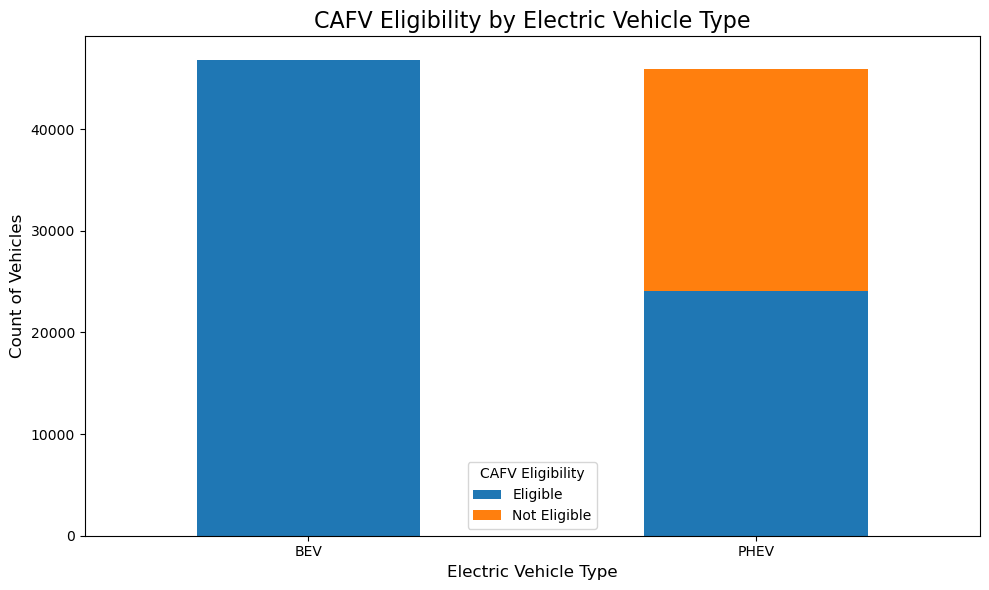

In [3]:
# Group the data by 'Electric Vehicle Type' and 'CAFV Eligibility Simple'
grouped_data = data.groupby(['Electric Vehicle Type', 'CAFV Eligibility Simple']).size().unstack()

# Plot the stacked bar chart
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add labels and title
plt.title("CAFV Eligibility by Electric Vehicle Type", fontsize=16)
plt.xlabel("Electric Vehicle Type", fontsize=12)
plt.ylabel("Count of Vehicles", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="CAFV Eligibility", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

The chart shows CAFV eligibility for BEVs and PHEVs. All BEVs are eligible, with around 50,000 vehicles in this category. PHEVs are divided into eligible and ineligible groups. A significant portion of PHEVs is not eligible, while the eligible count is slightly lower than that of BEVs. This indicates a policy preference for BEVs over PHEVs.

C:\Users\chezk\AppData\Local\Temp\ipykernel_20940\2591472662.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(['Electric Range Bin', 'CAFV Eligibility Simple']).size().unstack(fill_value=0)


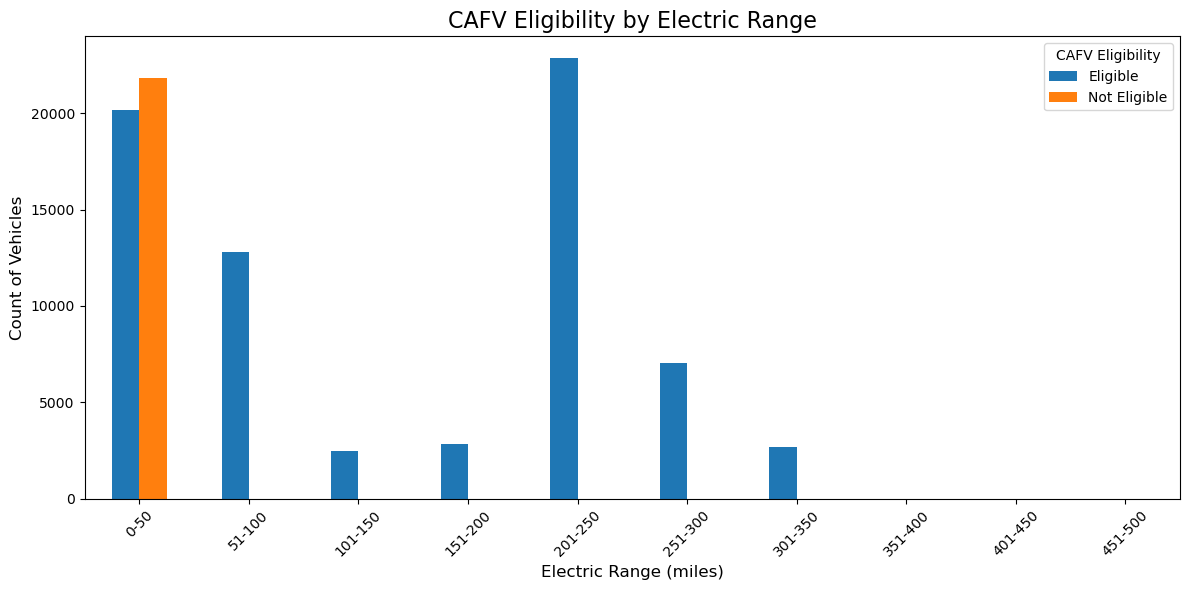

In [4]:
# Define bins for Electric Range
bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
labels = ['0-50', '51-100', '101-150', '151-200', '201-250', '251-300', '301-350', '351-400', '401-450', '451-500']
data['Electric Range Bin'] = pd.cut(data['Electric Range'], bins=bins, labels=labels, right=False)

# Group data by 'Electric Range Bin' and 'CAFV Eligibility Simple'
grouped_data = data.groupby(['Electric Range Bin', 'CAFV Eligibility Simple']).size().unstack(fill_value=0)

# Plot the bar chart
grouped_data.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add labels and title
plt.title("CAFV Eligibility by Electric Range", fontsize=16)
plt.xlabel("Electric Range (miles)", fontsize=12)
plt.ylabel("Count of Vehicles", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="CAFV Eligibility", fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

Vehicles with a range of 0-50 miles have the highest count, but many are not eligible for CAFV. All vehicles with a range of 51-100 miles are eligible, though their count is smaller. Vehicles with ranges of 101-150 and 151-200 miles are fewer, but all are eligible. The 201-250 mile range has the largest number of eligible vehicles. Counts decrease for ranges of 251-300 and 301-350 miles, but all remain eligible. No vehicles are seen beyond 350 miles. Most vehicles with over 50 miles of range are eligible, while many below 50 miles are not.

<Figure size 1000x600 with 0 Axes>

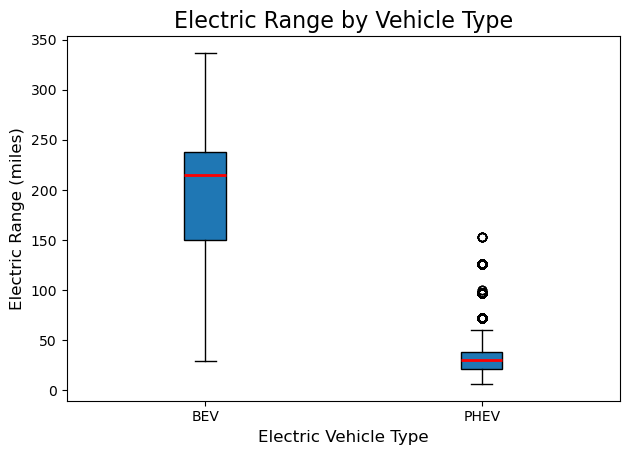

In [5]:
# Filter the data for only the relevant columns and drop rows with missing values
filtered_data = data[['Electric Vehicle Type', 'Electric Range']].dropna()

# Plot the box plot
plt.figure(figsize=(10, 6))
filtered_data.boxplot(column='Electric Range', by='Electric Vehicle Type', grid=False, patch_artist=True,
                      boxprops=dict(facecolor='#1f77b4', color='black'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'))

# Add labels and title
plt.title("Electric Range by Vehicle Type", fontsize=16)
plt.suptitle("")  # Remove the default Pandas boxplot subtitle
plt.xlabel("Electric Vehicle Type", fontsize=12)
plt.ylabel("Electric Range (miles)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

The box plot compares the electric range (in miles) of two types of electric vehicles: Battery Electric Vehicles (BEV) and Plug-in Hybrid Electric Vehicles (PHEV). The BEVs generally have a significantly higher range compared to PHEVs, with a median around 225 miles, while the median range for PHEVs is much lower, around 30 miles. The BEV data shows a wider range, with values extending from about 50 to 350 miles, whereas the PHEV range is more compact, with several outliers beyond the upper whisker. This suggests that BEVs typically provide a longer driving range, but with more variability compared to PHEVs.

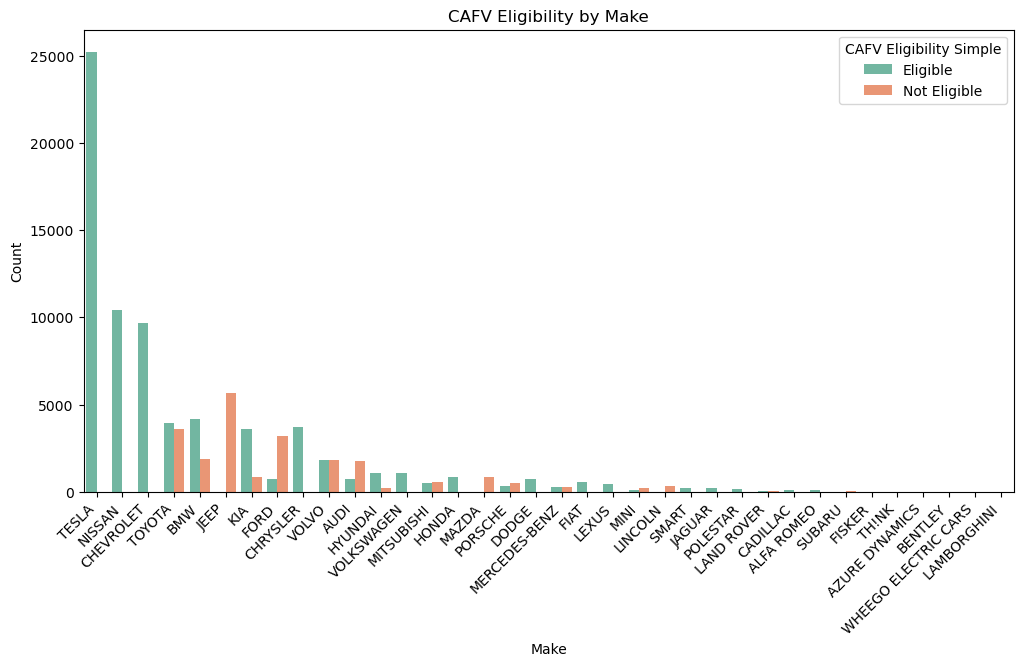

In [6]:
# Ensure 'CAFV Eligibility Simple' is treated as a categorical variable
data['CAFV Eligibility Simple'] = data['CAFV Eligibility Simple'].astype(str)

# Plot CAFV eligibility by Make
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Make', hue='CAFV Eligibility Simple', palette='Set2', order=data['Make'].value_counts().index)
plt.title('CAFV Eligibility by Make')
plt.xlabel('Make')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='CAFV Eligibility Simple')
plt.show()


The bar chart highlights the distribution of CAFV (Clean Alternative Fuel Vehicle) eligibility across various vehicle makes. Tesla stands out as the dominant make in the "Eligible" category, with over 25,000 vehicles, significantly surpassing all other brands. Nissan and Chevrolet follow with substantial counts in the eligibility category, although they also have notable representation in the "Not Eligible" category. Toyota and BMW show balanced contributions to both eligibility statuses, with slightly higher counts of eligible vehicles. Other brands such as Ford, Hyundai, Volvo, and Audi exhibit a mix of eligibility statuses but with generally lower counts compared to the top-performing makes. At the lower end, brands like Lamborghini, Azure Dynamics, and Wheego Electric Cars contribute minimally, with very few vehicles across eligibility statuses

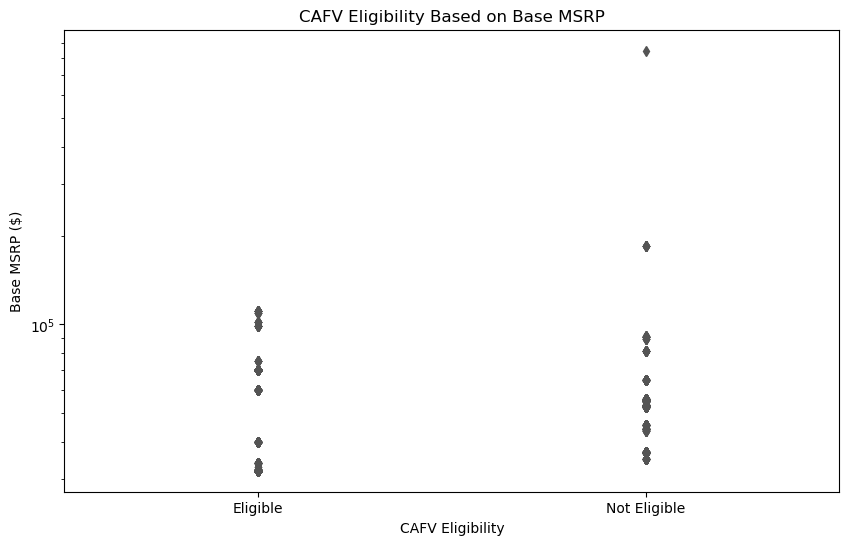

In [7]:
# Plot CAFV eligibility by Base MSRP
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='CAFV Eligibility Simple', y='Base MSRP', palette='muted')
plt.title('CAFV Eligibility Based on Base MSRP')
plt.xlabel('CAFV Eligibility')
plt.ylabel('Base MSRP ($)')
plt.yscale('log')  # Log scale if there's a wide range of prices
plt.show()

The scatter plot compares CAFV eligibility with base MSRP. Vehicles in both the "Eligible" and "Not Eligible" categories are distributed across a similar price range, mostly clustered below $100,000. However, there are some outliers in the "Not Eligible" category with significantly higher base MSRPs. This suggests that eligibility is not strongly correlated with price, but higher-end vehicles are more likely to be ineligible.

From the graphical analysis, several key insights emerge regarding CAFV eligibility. The bar chart analyzing vehicle make reveals that Tesla dominates the "Eligible" category with over 25,000 vehicles, far exceeding all other brands, followed by Nissan and Chevrolet, which also show significant counts for eligibility. Toyota, BMW, and other mainstream brands contribute moderately but with a more balanced split between eligibility and non-eligibility, while smaller or luxury brands like Lamborghini and Azure Dynamics contribute minimally. The scatter plot examining the relationship between base MSRP and CAFV eligibility shows that most vehicles, regardless of their eligibility status, are clustered below $100,000. However, some outliers in the "Not Eligible" category have significantly higher MSRPs, indicating that higher-priced vehicles are less likely to qualify. Overall, the analysis highlights Tesla's leadership in the clean alternative fuel vehicle market and suggests that while eligibility is influenced by various factors, it does not correlate strongly with base price, as both eligible and non-eligible vehicles span a similar price range.

In [8]:
# Part 2

In [9]:
for column in data.columns:
    print(f"{column} unique value counts:\n{data[column].value_counts()}\n")


State unique value counts:
State
WA    92676
Name: count, dtype: int64

Model Year unique value counts:
Model Year
2018    14214
2020    12167
2019    10826
2024     9215
2017     8294
2023     7711
2016     5431
2021     4725
2015     4685
2022     4559
2013     4243
2014     3433
2012     1531
2025      888
2011      696
2010       24
2008       22
2000        7
2002        2
1999        2
2003        1
Name: count, dtype: int64

Make unique value counts:
Make
TESLA                   25228
NISSAN                  10406
CHEVROLET                9697
TOYOTA                   7585
BMW                      6075
JEEP                     5646
KIA                      4451
FORD                     3912
CHRYSLER                 3700
VOLVO                    3630
AUDI                     2465
HYUNDAI                  1309
VOLKSWAGEN               1092
MITSUBISHI               1041
HONDA                     869
MAZDA                     839
PORSCHE                   829
DODGE                  

In [10]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing Values Per Column:\n", missing_values[missing_values > 0])


Missing Values Per Column:
 Series([], dtype: int64)


In [11]:
# Drop columns that may not be useful for modeling
data = data.drop(columns=['State', 'Base MSRP'])

In [12]:
# Convert 'Legislative District' to integer
data['Legislative District'] = data['Legislative District'].astype('Int64')

In [13]:
# Convert categorical variables to dummy variables (excluding 'Make')
data = pd.get_dummies(data, columns=['Electric Vehicle Type', 'CAFV Eligibility Simple', 'Make'], drop_first=True)

In [14]:
# Display cleaned dataset info
data.info()
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92676 entries, 0 to 92675
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Model Year                            92676 non-null  int64   
 1   Electric Range                        92676 non-null  int64   
 2   Legislative District                  92676 non-null  Int64   
 3   Electric Range Bin                    92676 non-null  category
 4   Electric Vehicle Type_PHEV            92676 non-null  bool    
 5   CAFV Eligibility Simple_Not Eligible  92676 non-null  bool    
 6   Make_AUDI                             92676 non-null  bool    
 7   Make_AZURE DYNAMICS                   92676 non-null  bool    
 8   Make_BENTLEY                          92676 non-null  bool    
 9   Make_BMW                              92676 non-null  bool    
 10  Make_CADILLAC                         92676 non-null  bool    
 11  Ma

During the data cleaning and transformation process, several steps were taken to ensure data consistency, accuracy, and usability for analysis. First, the dataset was loaded and inspected to identify missing values and data types, ensuring a clear understanding of the structure. The 'Legislative District' column was converted to an integer format to standardize numeric representation and facilitate sorting, filtering, and grouping operations. To analyze the impact of Clean Alternative Fuel Vehicle (CAFV) eligibility, data was grouped by 'Electric Vehicle Type' and 'CAFV Eligibility Simple' to visualize trends. The 'Electric Range' column was categorized into bins, making it easier to analyze variations in eligibility across different range segments. The state column was dropped as it only contained 1 value. The MSRP column was dropped because the vast majority of the rows have the value 0. To prepare for machine learning and statistical analysis, categorical variables such as 'Make,' 'Electric Vehicle Type,' and 'CAFV Eligibility Simple' were converted into dummy variables using one-hot encoding, ensuring compatibility with numerical algorithms while preventing multicollinearity. Finally, visualizations such as box plots and stacked bar charts were created to highlight relationships between electric vehicle characteristics and policy incentives. These transformations collectively enhanced data quality, enabling meaningful insights into electric vehicle adoption, range patterns, and policy impact.

In [15]:
# milestone 3

In [16]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [17]:
data = data.drop(columns=['Electric Range Bin'])

In [18]:
# Define features (X) and target (y)
target_column = "CAFV Eligibility Simple_Not Eligible"
X = data.drop(columns=[target_column])  # Features
y = data[target_column]  # Target

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Standardizing features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9990828657747087

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     14179
        True       1.00      1.00      1.00      4357

    accuracy                           1.00     18536
   macro avg       1.00      1.00      1.00     18536
weighted avg       1.00      1.00      1.00     18536



In [22]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     14179
        True       1.00      1.00      1.00      4357

    accuracy                           1.00     18536
   macro avg       1.00      1.00      1.00     18536
weighted avg       1.00      1.00      1.00     18536



In [25]:
# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     14179
        True       1.00      1.00      1.00      4357

    accuracy                           1.00     18536
   macro avg       1.00      1.00      1.00     18536
weighted avg       1.00      1.00      1.00     18536



The purpose of the Logistic Regression, Random Forest, and XGBoost models was to classify CAFV Eligibility, which determines whether electric vehicles qualify for Clean Alternative Fuel Vehicle incentives. These models were trained to predict CAFV Eligibility based on various features related to electric vehicles, such as type and electric range. Accurate classification is crucial for understanding the distribution of eligible vehicles and potentially guiding policy decisions or marketing strategies. Logistic Regression achieved an accuracy of 99.91% with perfect precision, recall, and F1-scores, demonstrating its effectiveness while maintaining model interpretability. Both Random Forest and XGBoost outperformed Logistic Regression with perfect accuracy of 100% and flawless classification metrics, showcasing their powerful predictive capabilities. The exceptional performance of all three models suggests that the dataset features are highly distinguishable, leading to minimal misclassifications. However, the perfect scores for Random Forest and XGBoost may indicate potential overfitting. Overall, XGBoost and Random Forest provide the highest accuracy, making them suitable for maximizing classification performance, while Logistic Regression offers slightly lower accuracy but better interpretability for decision-making insights.